### SubGraphs

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

In [14]:
class MathState(TypedDict):
    x: int
    y: int
    ans: int
    message: str

Child Subgraph

In [15]:
# Node 1    
def square_numbers(state: MathState) -> MathState:
    return {
        "x": state["x"] ** 2,
        "y": state["y"] ** 2,
        "ans": state["ans"]
    }
    
# Node 2
def add_numbers(state: MathState) -> MathState:
    return {
        "x": state["x"],
        "y": state["y"],
        "ans": state["x"] + state["y"]
    }

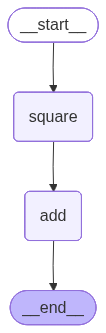

In [16]:
# Graph build up
child_graph = StateGraph(MathState)

child_graph.add_node("square", square_numbers)
child_graph.add_node("add", add_numbers)

child_graph.add_edge(START, "square")
child_graph.add_edge("square", "add")
child_graph.add_edge("add", END)

childNode = child_graph.compile()
childNode

#### Parent Graph

In [ ]:
def update_message(state: MathState):
    return {
        "message": f"Variables: x={state['x']}, y={state['y']}",
    }
    
def call_child(state: MathState) -> MathState:
    return childNode.invoke(state) # calling child subgraph within a node

Method1 - Calling child subgraph within a node

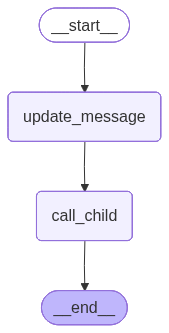

In [21]:
graph1 = StateGraph(MathState)

graph1.add_node("update_message", update_message)
graph1.add_node("call_child", call_child)
graph1.add_edge(START, "update_message")
graph1.add_edge("update_message", "call_child")
graph1.add_edge("call_child", END)

worfklow1 = graph1.compile()
worfklow1

In [22]:
res1 = worfklow1.invoke({
    "x": 2,
    "y": 3,
    "ans": 0,
    "message": ""
})
res1

{'x': 4, 'y': 9, 'ans': 13, 'message': 'Variables: x=2, y=3'}

Adding Child subgraph as node

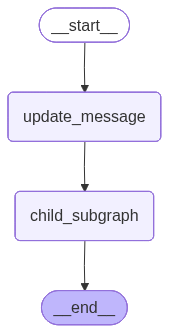

In [23]:
graph2 = StateGraph(MathState)

graph2.add_node("update_message", update_message)
graph2.add_node("child_subgraph", childNode) # subgraph as node

graph2.add_edge(START, "update_message")
graph2.add_edge("update_message", "child_subgraph")
graph2.add_edge("child_subgraph", END)

worfklow2 = graph2.compile()
worfklow2

In [24]:
res2 = worfklow2.invoke({
    "x": 2,
    "y": 3,
    "ans": 0,
    "message": ""
})
res2

{'x': 4, 'y': 9, 'ans': 13, 'message': 'Variables: x=2, y=3'}